# KV Cache 及架构演进

> 训练可以同时预测序列中的多个位置，自回归生成却要逐个产生 Token，并反复访问已经出现的内容。KV Cache 保存历史 K、V 来避免重复计算，但 Llama-7B 在 32K 上下文中仅这部分就需要约 16 GB FP16 显存。
>
> 这笔显存账推动了三代结构变化：
>
> **MHA** 为每个 Query 头保存独立的 K、V。
>
> **MQA 与 GQA** 让多个 Query 头共享 K/V 头。
>
> **MLA** 则把 K、V 压缩为更短的 latent 表示。
>
> 压缩并不是单独替换一个矩阵。头共享会改变 Attention 的表达方式，MLA 还会与 RoPE 的旋转结构发生冲突。后面的实现与实验将同时核对缓存大小、计算结果和位置编码的处理方式。

生成新 Token 时，历史位置的 K、V 已经由各自的 hidden state 计算完成。后续 Token 到来不会改变这些历史结果，因此重复计算只会增加开销。**KV Cache** 将它们保存下来，使每一步只需要计算新位置的 K、V。

缓存也会占用显存。以 32 层、32 个头、每头 128 维的模型为例，一个 Token 在一层需要保存 4096 个 K 数值和 4096 个 V 数值。扩展到 32K 上下文后，仅 FP16 KV Cache 就约为 16 GB。

减少这笔开销有两类思路：MQA 与 GQA 让多个 Query 头共享 K/V 头，MLA 则先把 K、V 压缩到更短的 latent 表示。下面从缓存中究竟保存了什么开始，逐步比较三种结构。

## 本节要点

通过这一节的学习，以下问题应该能够回答：

1. KV Cache 是什么？它用什么东西换来了速度？
2. MQA、GQA 是怎么缩小 KV Cache 的？各自的代价是什么？
3. MLA 为什么能把压缩比从几倍拉到几十倍？
4. RoPE 和 MLA 为什么冲突？DeepSeek 是怎么解决的？


## 1. 生成时到底在重复计算什么

先看一个具体例子。假设模型已经生成了 4 个 token，正在生成第 5 个：

```text
第 4 步结束: [t1, t2, t3, t4]
第 5 步:     [t1, t2, t3, t4, t5?]
                          ↑
             新 token 的 query 要和 t1~t4 的 key、value 做 attention
```

注意一个事实：t1 的 K 和 V 是由 t1 的 hidden state 乘投影矩阵得到的。第 5 步时，t1 的 hidden state 变了吗？没有——decoder-only 模型里 t1 看不到它后面的 token，它的 hidden state 在算完那一刻就定死了。所以第 4 步算过的 k1、v1，第 5 步直接能用。

如果没有缓存，第 5 步要把 t1~t4 的 K、V 全部重算一遍；生成到第 100 个 token 时，前面 99 个全部重算——计算量随生成长度平方增长。把每步算出的 K、V 存下来复用，每步只算新 token 的一份，计算量降回线性。

这笔「存下来」的账好不好算？先用代码验证前提：历史 token 的 K、V 确实不变。


In [1]:
# 验证：生成新 token 时，历史 token 的 K 确实不变
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

d_model, d_k = 8, 4
W_K = nn.Linear(d_model, d_k, bias=False)

# 第 4 步结束：已经算了 4 个 token 的 hidden state 和 K
h_4 = torch.randn(1, 4, d_model)
k_4 = W_K(h_4)

# 第 5 步：来了一个新 token，整个序列变成 5 个
h_new = torch.randn(1, 1, d_model)
h_5 = torch.cat([h_4, h_new], dim=1)
k_5 = W_K(h_5)  # ← 不用缓存时的做法：全量重算

print(f"k_4: {tuple(k_4.shape)}  ← 4 个 token 的 K（上一步已算过）")
print(f"k_5: {tuple(k_5.shape)}  ← 5 个 token 的 K（全量重算的结果）")
print()
print(f"重算的前 4 个位置 == 缓存的 k_4: {torch.allclose(k_5[:, :4], k_4)}")
print()
# 增量做法：只算新 token 的一份，再和历史拼接
k_new = W_K(h_new)
k_5_incremental = torch.cat([k_4, k_new], dim=1)
print(f"增量只算 1 份（{tuple(k_new.shape)}），拼接结果 == 全量重算: "
      f"{torch.allclose(k_5_incremental, k_5)}")
print()
print("关键观察：历史 token 的 K 重算一遍结果完全一样——纯浪费。")
print("存下来复用，每步只算新 token 的一份，这就是 KV Cache 的全部思想。")


k_4: (1, 4, 4)  ← 4 个 token 的 K（上一步已算过）
k_5: (1, 5, 4)  ← 5 个 token 的 K（全量重算的结果）

重算的前 4 个位置 == 缓存的 k_4: True

增量只算 1 份（(1, 1, 4)），拼接结果 == 全量重算: True

关键观察：历史 token 的 K 重算一遍结果完全一样——纯浪费。
存下来复用，每步只算新 token 的一份，这就是 KV Cache 的全部思想。


### Cache 解决了速度，带来了显存

KV Cache 是用显存换速度。这笔账有多大？每个 token 在每一层都要存一对 (K, V)：

```text
每 token 每层 K+V 元素数 = num_heads × head_dim × 2
全部 KV Cache 元素数   = seq_len × num_layers × 上面的值
字节数                = 元素数 × bytes_per_element
```

乘 2 是因为 K 和 V 各存一份。下面用 Llama-7B 的配置，把这笔账完整算一遍。


In [2]:
# 手算 KV Cache 占用：Llama-7B 的具体数字

hidden_size = 4096
num_layers = 32
num_heads = 32
head_dim = hidden_size // num_heads  # 128
seq_len = 32768  # 32K 上下文
bytes_per_element = 2  # FP16

# MHA：每个 token 每层存 num_heads 对 (K, V)
elements_per_token_per_layer = num_heads * head_dim * 2  # 乘 2 是因为 K 和 V 各一份
total_elements = seq_len * num_layers * elements_per_token_per_layer
total_bytes = total_elements * bytes_per_element
total_gb = total_bytes / (1024 ** 3)

print(f"模型: hidden={hidden_size}, layers={num_layers}, heads={num_heads}, head_dim={head_dim}")
print(f"上下文: {seq_len} tokens, dtype=FP16")
print()
print(f"每 token 每层 K+V 元素数: {elements_per_token_per_layer}")
print(f"全部 KV Cache 元素数: {total_elements:,}")
print(f"KV Cache 总占用: {total_gb:.2f} GB")
print()
print(f"对比：Llama-7B 权重本身约 13 GB（FP16）")
print(f"关键观察：32K 上下文下，KV Cache 已经超过模型权重本身")


模型: hidden=4096, layers=32, heads=32, head_dim=128
上下文: 32768 tokens, dtype=FP16

每 token 每层 K+V 元素数: 8192
全部 KV Cache 元素数: 8,589,934,592
KV Cache 总占用: 16.00 GB

对比：Llama-7B 权重本身约 13 GB（FP16）
关键观察：32K 上下文下，KV Cache 已经超过模型权重本身


## 2. 第一代方案：少存几份 K/V（MQA 与 GQA）

再盯着账单看：`num_heads` 是个乘数——32 个头，每头一份 K、V。第一代压缩思路就盯上了它：能不能少存几份？

最激进的做法是 **MQA**（Multi-Query Attention）：32 个 query 头共用同一份 K、V。账单里的头数直接变成 1，KV Cache 缩小 32 倍。代价也直白：32 个头看到的 K、V 完全相同——多头注意力本来指望不同的头关注不同的信息，现在所有头戴同一副眼镜，多样性大幅下降。

折中的做法是 **GQA**（Grouped-Query Attention）：把 32 个头分成若干组，每组共用一份 K、V。比如分成 8 组，KV Cache 缩小 8 倍。组数是一个可调的旋钮：往 MQA 方向拧，省显存但伤能力；往 MHA 方向拧，则相反。

| 方案 | num_kv_heads | 相对 MHA 的 cache | 代表模型 |
|:---|:---|:---|:---|
| MHA | = num_heads | 1× | 原始 Transformer、GPT-2 |
| GQA | num_heads / 组数 | 1/组数 | Llama 2/3、Qwen、Mistral |
| MQA | 1 | 1/num_heads | PaLM、Falcon |

先用代码看清 GQA 的机制——cache 里只存几份，计算时再「借」给所有头。


In [3]:
# GQA 的机制：cache 里只存 4 份 K，计算时借给 32 个头

torch.manual_seed(42)

num_heads = 32
num_kv_heads = 4
head_dim = 128
seq_len = 10

# KV 侧：cache 里只存 4 份 K（真正占显存的就是它）
k_cache = torch.randn(1, num_kv_heads, seq_len, head_dim)
print(f"cache 里的 K: {tuple(k_cache.shape)}  ← 只有 {num_kv_heads} 份")

# Q 侧有 32 个头，每个头去「借」自己组的那一份
# repeat_interleave：把第 1 份复制 8 次、第 2 份复制 8 次……
k_expanded = k_cache.repeat_interleave(num_heads // num_kv_heads, dim=1)
print(f"展开后给 Q 用: {tuple(k_expanded.shape)}  ← {num_heads} 份（内容其实只有 4 种）")
print()
print("关键观察：计算时照常是 32 个头在跑，但 cache 只存 4 份——")
print("GQA 省的是存储，不是头的数量。")


cache 里的 K: (1, 4, 10, 128)  ← 只有 4 份
展开后给 Q 用: (1, 32, 10, 128)  ← 32 份（内容其实只有 4 种）

关键观察：计算时照常是 32 个头在跑，但 cache 只存 4 份——
GQA 省的是存储，不是头的数量。


In [4]:
# 三种注意力的 KV Cache 账单对比（Llama-7B 配置）


def kv_cache_gb(num_heads, head_dim, num_layers, seq_len, num_kv_heads):
    """算 KV Cache 的 GB 数"""
    per_token_per_layer = num_kv_heads * head_dim * 2  # K + V
    total = seq_len * num_layers * per_token_per_layer
    return total * 2 / (1024 ** 3)  # FP16


num_heads = 32
head_dim = 128
num_layers = 32
seq_len = 32768

configs = [
    ("MHA", num_heads),
    ("GQA-8", num_heads // 8),  # 8 组 → 4 个 KV 头
    ("GQA-4", num_heads // 4),  # 4 组 → 8 个 KV 头
    ("MQA", 1),
]

print(f"{'方案':<8}{'KV头数':<8}{'GB':<10}{'相对MHA'}")
print("-" * 40)
base = None
for name, n_kv in configs:
    gb = kv_cache_gb(num_heads, head_dim, num_layers, seq_len, n_kv)
    if base is None:
        base = gb
    print(f"{name:<8}{n_kv:<8}{gb:<10.2f}{gb / base:.2f}×")

print()
print("关键观察：MQA 把 cache 压到 1/32，但所有头看同一份 K/V，能力损失明显")
print("GQA 是工程上的主流折中：Llama 2 70B 用 8 组，Llama 3 8B 用 4 组")


方案      KV头数    GB        相对MHA
----------------------------------------
MHA     32      16.00     1.00×
GQA-8   4       2.00      0.12×
GQA-4   8       4.00      0.25×
MQA     1       0.50      0.03×

关键观察：MQA 把 cache 压到 1/32，但所有头看同一份 K/V，能力损失明显
GQA 是工程上的主流折中：Llama 2 70B 用 8 组，Llama 3 8B 用 4 组


### 这条路的极限

GQA 的旋钮拧到头就是 MQA。再往下压，就必须继续牺牲注意力质量——「头数」这个维度已经压干了。

还有别的维度可压吗？换个角度想：我们存的为什么是 K 和 V 本身？它们都是从 hidden state 投影出来的。能不能存一个更小的中间结果，需要的时候再「还原」出 K 和 V？这就是 MLA 的出发点。


## 3. 第二代方案：不存 K/V，存压缩向量（MLA）

标准 attention 里，hidden state `h` 经过两个投影矩阵得到 `K = W_K · h` 和 `V = W_V · h`。**MLA**（Multi-head Latent Attention，DeepSeek-V2 提出）把这一步拆成「先压缩、后还原」：

```text
c = W_DK · h     # 压缩：把 h 投到一个低维 latent 向量（d_c 维）
K = W_UK · c     # 还原：从 c 投影回 K
V = W_UV · c     # 还原：从 c 投影回 V
```

推理时 cache 里只存 `c`，K 和 V 不存——要用的时候现算。因为 `d_c` 远小于 `num_heads × head_dim`，账单大幅缩短。

为什么模型能力基本不掉？因为 `W_DK` 和 `W_UK / W_UV` 都是训练时学出来的：模型在训练中自己学会把「注意力真正需要的信息」压进 `c`，主动丢掉冗余。这和 GQA 有本质区别——GQA 是在成品上砍数量，MLA 是让模型自己学会用更小的瓶子装必要的酒。

先手算一下压缩比：DeepSeek-V2 取 `d_c = 512`，对比 `num_heads=128、head_dim=128` 的 MHA。


In [5]:
# MLA 的压缩比：手算具体数字

# DeepSeek-V2 量级的注意力配置
num_heads = 128
head_dim = 128
mha_per_token_per_layer = num_heads * head_dim * 2  # K + V 各一份

# MLA：K 和 V 共用一个 d_c 维的 latent
d_c = 512
mla_per_token_per_layer = d_c

print(f"MHA 每 token 每层: {mha_per_token_per_layer} 元素")
print(f"  = {num_heads} heads × {head_dim} dim × 2 (K+V)")
print()
print(f"MLA 每 token 每层: {mla_per_token_per_layer} 元素")
print(f"  = d_c = {d_c}（K 和 V 共用同一个 latent）")
print()
print(f"压缩比: {mha_per_token_per_layer / mla_per_token_per_layer:.0f}×")
print(f"节省: {(1 - mla_per_token_per_layer / mha_per_token_per_layer) * 100:.1f}%")
print()
print("关键观察：GQA 最多省一个常数倍（组数），MLA 省的是量级")


MHA 每 token 每层: 32768 元素
  = 128 heads × 128 dim × 2 (K+V)

MLA 每 token 每层: 512 元素
  = d_c = 512（K 和 V 共用同一个 latent）

压缩比: 64×
节省: 98.4%

关键观察：GQA 最多省一个常数倍（组数），MLA 省的是量级


## 4. 从零实现一个简化 MLA

下面写教学版 MLA。两条路径分开看：

- **Q 路径**：和标准 attention 完全一样，`W_Q` 投影出 `num_heads` 个 query 头
- **KV 路径**：先 `W_DK` 压到 `d_c` 维 latent，再 `W_UK` / `W_UV` 分别还原出 K、V

为了突出主干，这个版本不加 RoPE——RoPE 和 MLA 的冲突是第 6 节的主角，到时候单独处理。


In [6]:
# 简化版 MLA：核心是 latent 压缩机制


class SimpleMLA(nn.Module):
    """教学版 MLA，展示 latent 压缩机制

    参数:
        d_model: 模型 hidden 维度
        num_heads: query 头数
        head_dim: 每个头的维度
        d_c: latent 维度（K 和 V 共用）
    """

    def __init__(self, d_model, num_heads, head_dim, d_c):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.d_c = d_c

        # Q 路径：标准投影，和普通 attention 一样
        self.W_Q = nn.Linear(d_model, num_heads * head_dim, bias=False)

        # KV 路径：先压缩到 latent c，再还原回 K / V
        self.W_DK = nn.Linear(d_model, d_c, bias=False)               # down
        self.W_UK = nn.Linear(d_c, num_heads * head_dim, bias=False)  # up to K
        self.W_UV = nn.Linear(d_c, num_heads * head_dim, bias=False)  # up to V

        # 输出投影
        self.W_O = nn.Linear(num_heads * head_dim, d_model, bias=False)

    def forward(self, x):
        """x: [batch, seq_len, d_model]，返回 (output, latent c)"""
        B, S, D = x.shape

        # Q 路径
        Q = self.W_Q(x).view(B, S, self.num_heads, self.head_dim)

        # KV 路径：c 就是要缓存的 latent
        c = self.W_DK(x)                                          # [B, S, d_c]
        K = self.W_UK(c).view(B, S, self.num_heads, self.head_dim)
        V = self.W_UV(c).view(B, S, self.num_heads, self.head_dim)

        # 标准 attention 计算（教学版，不加 mask）
        Q = Q.transpose(1, 2)  # [B, heads, S, head_dim]
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        scores = Q @ K.transpose(-1, -2) / (self.head_dim ** 0.5)
        attn = scores.softmax(dim=-1)
        out = attn @ V

        out = out.transpose(1, 2).reshape(B, S, self.num_heads * self.head_dim)
        return self.W_O(out), c  # 把 c 也返回，方便观察 cache


# 用一个小配置测试
torch.manual_seed(42)
d_model, num_heads, head_dim, d_c = 64, 4, 16, 16

mla = SimpleMLA(d_model, num_heads, head_dim, d_c)
x = torch.randn(1, 10, d_model)
out, c = mla(x)

print(f"输入 shape: {tuple(x.shape)}")
print(f"输出 shape: {tuple(out.shape)}")
print(f"latent c shape: {tuple(c.shape)}  ← 这就是 cache 里存的全部")
print()
mha_elems = num_heads * head_dim * 2
print(f"标准 MHA 每 token 每层要缓存 K+V = {mha_elems} 个元素")
print(f"MLA 每 token 每层只缓存 c = {d_c} 个元素")
print(f"压缩比: {mha_elems / d_c:.0f}×")


输入 shape: (1, 10, 64)
输出 shape: (1, 10, 64)
latent c shape: (1, 10, 16)  ← 这就是 cache 里存的全部

标准 MHA 每 token 每层要缓存 K+V = 128 个元素
MLA 每 token 每层只缓存 c = 16 个元素
压缩比: 8×


## 5. 实验：三代方案放在一起比

把 MHA / GQA / MLA 放到同一张图上，看 cache 随上下文长度的增长。配置取 DeepSeek-V2 的量级：`num_layers=60, num_heads=128, head_dim=128, d_c=512`。


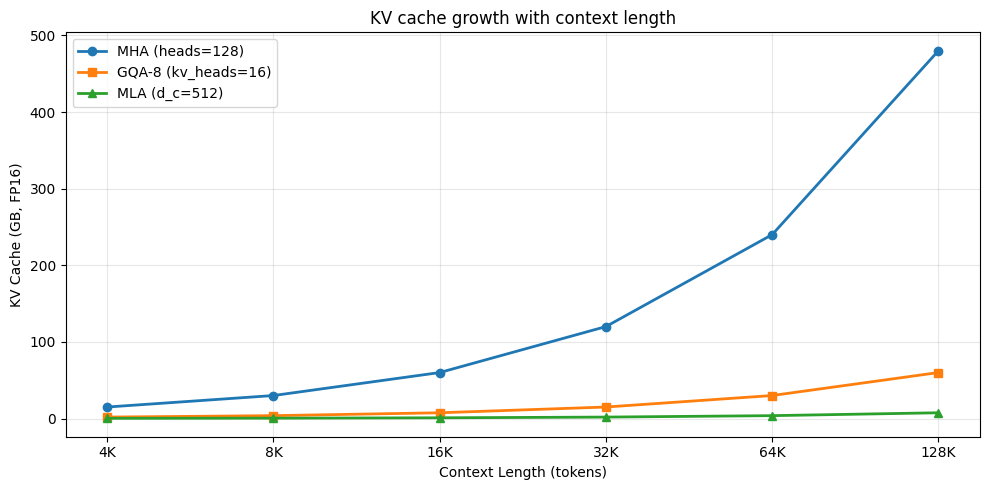

128K 上下文下的 KV Cache：
  MHA:     480.0 GB
  GQA-8:    60.0 GB  (8× 压缩)
  MLA:       7.5 GB  (64× 压缩)

关键观察：在长上下文场景，MLA 比 GQA 又多省了一个数量级


In [7]:
# 三代方案的 cache 随上下文长度的增长曲线


def mha_cache_gb(num_heads, head_dim, num_layers, seq_len):
    """标准 MHA 的 KV cache（GB）"""
    return seq_len * num_layers * num_heads * head_dim * 2 * 2 / (1024 ** 3)


def gqa_cache_gb(num_heads, head_dim, num_layers, seq_len, num_groups):
    """GQA 的 KV cache（GB），num_groups 组共用 KV"""
    num_kv_heads = num_heads // num_groups
    return seq_len * num_layers * num_kv_heads * head_dim * 2 * 2 / (1024 ** 3)


def mla_cache_gb(d_c, num_layers, seq_len):
    """MLA 的 KV cache（GB），只存 latent（RoPE 旁路第 6 节再算）"""
    return seq_len * num_layers * d_c * 2 / (1024 ** 3)


# DeepSeek-V2 量级的配置
num_layers = 60
num_heads = 128
head_dim = 128
d_c = 512

seq_lens = [4096, 8192, 16384, 32768, 65536, 131072]
mha_sizes = [mha_cache_gb(num_heads, head_dim, num_layers, s) for s in seq_lens]
gqa_sizes = [gqa_cache_gb(num_heads, head_dim, num_layers, s, 8) for s in seq_lens]
mla_sizes = [mla_cache_gb(d_c, num_layers, s) for s in seq_lens]

plt.figure(figsize=(10, 5))
plt.plot(seq_lens, mha_sizes, 'o-', label=f'MHA (heads={num_heads})', linewidth=2)
plt.plot(seq_lens, gqa_sizes, 's-', label=f'GQA-8 (kv_heads={num_heads // 8})', linewidth=2)
plt.plot(seq_lens, mla_sizes, '^-', label=f'MLA (d_c={d_c})', linewidth=2)
plt.xlabel('Context Length (tokens)')
plt.ylabel('KV Cache (GB, FP16)')
plt.title('KV cache growth with context length')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.xticks(seq_lens, [f'{s // 1024}K' for s in seq_lens])
plt.tight_layout()
plt.show()

print("128K 上下文下的 KV Cache：")
print(f"  MHA:   {mha_sizes[-1]:7.1f} GB")
print(f"  GQA-8: {gqa_sizes[-1]:7.1f} GB  ({mha_sizes[-1] / gqa_sizes[-1]:.0f}× 压缩)")
print(f"  MLA:   {mla_sizes[-1]:7.1f} GB  ({mha_sizes[-1] / mla_sizes[-1]:.0f}× 压缩)")
print()
print("关键观察：在长上下文场景，MLA 比 GQA 又多省了一个数量级")


## 6. 绕不开的麻烦：RoPE

到目前为止一切顺利，但有一个隐藏的冲突：RoPE。

回忆位置编码那一节：RoPE 是作用在 Q 和 K 上的旋转，让点积只依赖相对位置。问题就出在这——MLA 想把 K 拆掉不存（要用时从 `c` 还原），而 RoPE 必须先有 K 才能旋转。

能不能把 RoPE 吸收进投影矩阵？不能。RoPE 对 K 的每一对相邻维度做不同角度的旋转，角度随位置变化，写不成 `K_rotated = R · K` 里那个固定的 R。所以推理时为了加 RoPE 把 K 还原出来，等于把压缩的好处又还回去了。

DeepSeek-V2 的解法叫 **decoupled RoPE**（解耦 RoPE）：位置信息不走 latent 主路，单独开一条小旁路——

```text
主路（不带位置）: c = W_DK · h             → 进 cache
旁路（带位置）:   k_rope = RoPE(W_KR · h)  → 也进 cache（很小）
最终每头的 K = concat([W_UK · c 中该头的部分, k_rope])
```

关键设计：`k_rope` 是一个**所有头共享**的向量，维度 `d_r = 64`——不是每头一份。于是 MLA 的真实账单：

```text
每 token 每层 = d_c + d_r = 512 + 64 = 576 个元素
```


In [8]:
# MLA 的真实账单：latent + RoPE 旁路（DeepSeek-V2 配置）

num_heads = 128
head_dim = 128
d_c = 512  # latent 维度
d_r = 64   # RoPE 旁路维度（所有头共享一份）

mha_per_token_per_layer = num_heads * head_dim * 2   # K + V 各一份
mla_per_token_per_layer = d_c + d_r                  # latent + 共享的 RoPE 向量

print(f"MHA 每 token 每层: {mha_per_token_per_layer:6d} 元素")
print(f"MLA 每 token 每层: {mla_per_token_per_layer:6d} 元素"
      f"（latent {d_c} + RoPE 旁路 {d_r}）")
print()
print(f"压缩比: {mha_per_token_per_layer / mla_per_token_per_layer:.0f}×")
print()
print("关键观察：RoPE 旁路只有 64 维、所有头共享，几乎不侵蚀压缩收益")
print("如果旁路按每头一份存（128×64），账单会膨胀到 8704——共享是关键设计")


MHA 每 token 每层:  32768 元素
MLA 每 token 每层:    576 元素（latent 512 + RoPE 旁路 64）

压缩比: 57×

关键观察：RoPE 旁路只有 64 维、所有头共享，几乎不侵蚀压缩收益
如果旁路按每头一份存（128×64），账单会膨胀到 8704——共享是关键设计


## 7. 谁在用：MLA 的工程现状

MLA 已经不是论文玩具。DeepSeek-V2 首次大规模落地，DeepSeek-V3 沿用，Kimi K2 也采用了 MLA。换来的是长上下文推理的成本优势：

- cache 缩小一个数量级——同样的显存能装下更长的上下文，或者服务更多并发请求
- 生成主要受显存带宽限制，cache 越小，每生成一个 token 要读的显存越少，长上下文场景反而更快

代价也有：K、V 要经过「压缩再还原」两次矩阵乘，训练和推理的计算量都增加；推理框架（vLLM、SGLang、TensorRT-LLM）对 MLA 的支持比 GQA 新，成熟度仍在追赶。

一句话总结这一节的演进：**GQA 压的是「份数」，MLA 压的是「内容」——前者省常数倍，后者省一个量级。**


## 小结

- [ ] 生成第 N 个 token 时，历史 token 的 K、V 不变——KV Cache 把重复计算变成显存占用，计算量从平方降回线性
- [ ] 7B 模型在 32K 上下文下 KV Cache 约 16 GB，已经超过模型权重本身（约 13 GB）
- [ ] 第一代方案（MQA / GQA）减少 KV 头数：MQA 太激进，GQA 用分组共享在省显存和保能力之间取折中，是当前主流
- [ ] 第二代方案（MLA）不再存 K、V，只存低维 latent `c`，需要时投影还原；压缩比可达几十倍
- [ ] RoPE 必须作用在 K 上，与「不存 K」冲突；decoupled RoPE 用一条所有头共享的小旁路（d_r=64）解决
- [ ] DeepSeek-V2 / V3、Kimi K2 都在用 MLA；代价是计算略增、推理框架支持较新

参考：[DeepSeek-V2](https://arxiv.org/abs/2405.04434)、[DeepSeek-V3](https://arxiv.org/abs/2412.19437)、[Kimi K2](https://arxiv.org/abs/2507.20534)、[GQA 论文](https://arxiv.org/abs/2305.13245)、[MQA 论文](https://arxiv.org/abs/1911.02150)。

下一节回到训练主线，解决「单卡装不下」的问题：多张 GPU 如何分工、显存怎么切到卡上——分布式训练基础。


## 作业

> 可以让 AI 帮忙解释思路、拆解步骤、检查方向是否正确，但不建议直接让 AI "做完这道题"。


**作业 1：KV Cache 大小计算**

给定模型配置：`hidden_size=4096, num_layers=32, num_heads=32, seq_len=16384, dtype=FP16`。算出 MHA 下的 KV Cache 占用多少 GB。

小提示：每 token 每层 K+V 元素数 = `num_heads × head_dim × 2`；总元素数 = `seq_len × num_layers × 该值`；GB = 总元素数 × 2 ÷ 1024³。


In [ ]:
# 作业 1：KV Cache 大小计算

hidden_size = 4096
num_layers = 32
num_heads = 32
head_dim = hidden_size // num_heads
seq_len = 16384
bytes_per_element = 2  # FP16

# TODO：把三引号里的内容替换成你的代码
elements_per_token_per_layer = """在这里算每 token 每层的 K+V 元素数"""
total_elements = """在这里算全部 KV Cache 元素数"""
total_gb = """在这里算总占用（GB）"""

assert not isinstance(elements_per_token_per_layer, str), "请先替换第一个三引号占位"
assert not isinstance(total_elements, str), "请先替换第二个三引号占位"
assert not isinstance(total_gb, str), "请先替换第三个三引号占位"

expected_eptpl = num_heads * head_dim * 2
expected_total = seq_len * num_layers * expected_eptpl
expected_gb = expected_total * bytes_per_element / (1024 ** 3)

assert elements_per_token_per_layer == expected_eptpl,     f"每 token 每层应为 {expected_eptpl}，你算的是 {elements_per_token_per_layer}"
assert total_elements == expected_total,     f"总元素数应为 {expected_total}，你算的是 {total_elements}"
assert abs(total_gb - expected_gb) < 0.01, f"应为 {expected_gb:.2f} GB，你算的是 {total_gb}"

print("✅ 作业 1 通过")
print(f"   每 token 每层 K+V: {elements_per_token_per_layer} 元素")
print(f"   总元素数: {total_elements:,}")
print(f"   KV Cache 总占用: {total_gb:.2f} GB")


**作业 2：GQA 分组后的 cache 大小**

给定 `num_heads=32, head_dim=128, num_groups=8`（8 组共用 KV），`num_layers=32, seq_len=32768, dtype=FP16`。算出 GQA-8 的 KV Cache 占用多少 GB。

小提示：真正的 KV 头数 = `num_heads // num_groups`；每 token 每层 = KV 头数 × head_dim × 2。


In [ ]:
# 作业 2：GQA 分组后的 cache 大小

num_heads = 32
head_dim = 128
num_groups = 8
num_layers = 32
seq_len = 32768
bytes_per_element = 2  # FP16

# TODO：把三引号里的内容替换成你的代码
num_kv_heads = """在这里算实际要存的 KV 头数"""
total_gb = """在这里算 GQA-8 的 KV Cache 总占用（GB）"""

assert not isinstance(num_kv_heads, str), "请先替换第一个三引号占位"
assert not isinstance(total_gb, str), "请先替换第二个三引号占位"

expected_kv_heads = num_heads // num_groups
expected_eptpl = expected_kv_heads * head_dim * 2
expected_gb = seq_len * num_layers * expected_eptpl * bytes_per_element / (1024 ** 3)

assert num_kv_heads == expected_kv_heads,     f"KV 头数应为 {expected_kv_heads}，你算的是 {num_kv_heads}"
assert abs(total_gb - expected_gb) < 0.01,     f"应为 {expected_gb:.2f} GB，你算的是 {total_gb}"

print("✅ 作业 2 通过")
print(f"   实际 KV 头数: {num_kv_heads}（{num_groups} 组共用）")
print(f"   GQA-8 的 KV Cache: {total_gb:.2f} GB（同样配置下 MHA 是 16 GB）")


**作业 3：补全简化 MLA 的 forward**

下面的 `SimpleMLA` 省略了 forward 里的 latent 压缩和 K、V 还原三行。补全它们，让 assert 通过。

小提示：参考第 4 节的实现。`c = self.W_DK(x)`；K 和 V 分别用 `W_UK` / `W_UV` 从 `c` 还原，别忘了 `.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)`。


In [ ]:
# 作业 3：补全简化 MLA 的 forward


class SimpleMLA(nn.Module):
    def __init__(self, d_model, num_heads, head_dim, d_c):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.d_c = d_c
        self.W_Q = nn.Linear(d_model, num_heads * head_dim, bias=False)
        self.W_DK = nn.Linear(d_model, d_c, bias=False)
        self.W_UK = nn.Linear(d_c, num_heads * head_dim, bias=False)
        self.W_UV = nn.Linear(d_c, num_heads * head_dim, bias=False)
        self.W_O = nn.Linear(num_heads * head_dim, d_model, bias=False)

    def forward(self, x):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.head_dim).transpose(1, 2)

        # TODO：补全下面三行
        c = None   # 压缩到 latent
        K = None   # 从 c 还原 K（view 成多头再 transpose 到 [B, heads, S, head_dim]）
        V = None   # 从 c 还原 V（同上）

        assert c is not None and K is not None and V is not None, "请先补全 c/K/V 三行"

        scores = Q @ K.transpose(-1, -2) / (self.head_dim ** 0.5)
        attn = scores.softmax(dim=-1)
        out = attn @ V
        out = out.transpose(1, 2).reshape(B, S, self.num_heads * self.head_dim)
        return self.W_O(out), c


# 验证
torch.manual_seed(42)
mla_hw = SimpleMLA(d_model=64, num_heads=4, head_dim=16, d_c=16)
x = torch.randn(1, 10, 64)
out, c = mla_hw(x)

assert out.shape == (1, 10, 64), f"输出 shape 应为 (1, 10, 64)，实际 {tuple(out.shape)}"
assert c.shape == (1, 10, 16), f"latent shape 应为 (1, 10, 16)，实际 {tuple(c.shape)}"
assert torch.isfinite(out).all(), "输出包含 NaN 或 Inf，可能 K/V 投影写错了"

print("✅ 作业 3 通过")
print(f"   输出 shape: {tuple(out.shape)}，latent shape: {tuple(c.shape)}")
print("   MLA 的核心是 latent 压缩：每 token 每层只缓存 d_c 维的 c")
